In [2]:
pip install --force-reinstall arch statsmodels pandas

  Using cached arch-8.0.0-cp311-cp311-win_amd64.whl.metadata (13 kB)
  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached arch-8.0.0-cp311-cp311-win_amd64.whl (937 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 2.8 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/12.6 MB 2.6 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/12.6 MB 2.8 MB/s eta 0:00:05
   ---- ----------------------------------- 1.6/12.6 MB 2.1 MB/s eta 0:00:06
   ---- ----------------------------------- 1.6/12.6 MB 2.1 MB/s eta 0:00:06
   ----- ---------------------------------- 1.8/12

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
causalexplain 0.9.4 requires scikit-learn<1.8.0,>=1.7.0, but you have scikit-learn 1.6.1 which is incompatible.
dodiscover 0.0.0.dev0 requires numpy<2.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
gretel-client 0.30.1 requires networkx==3.0, but you have networkx 3.6.1 which is incompatible.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.6 which is incompatible.
pygam 0.12.0 requires scipy<1.17,>=1.11.1, but you have scipy 1.17.1 which is incompatible.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy

# CIR Yield Curve Modelling: Stochastic Calculus, Financial Econometrics & Statistical Learning

**Finance Club, IIT Roorkee -- Open Projects 2026**  
*Analytical Research Notebook*

---

## Project Architecture

| Module | Theme | Tools |
|--------|-------|-------|
| **0** | Data Engineering & EDA | pandas, statsmodels, matplotlib |
| **1** | Stochastic Calculus & MCMC | MCMC, Fokker-Planck PDEs, Edgeworth expansions |
| **2** | Financial Econometrics | GARCH family, cointegration, Nelson-Siegel |
| **3** | Statistical & ML Modelling | Splines, Gradient Boosting, Random Forest |
| **4** | Critical Analysis | Limitations, extensions, risk implications |

# Module 0: Data Engineering & Preprocessing

## 0.1 Mathematical Framing

Let $\mathcal{Y}_t = \{y(t, \tau_i)\}_{i=1}^{9}$ denote the cross-section of continuously-compounded zero-coupon yields at date $t$ across maturities $\tau \in \{0.25, 0.5, 0.75, 1, 2, 5, 10, 20, 30\}$ years.

The raw series $\tilde{y}(t,\tau)$ is contaminated by measurement error $\varepsilon_t$:

$$\tilde{y}(t,\tau) = y(t,\tau) + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_\varepsilon^2)$$

**Preprocessing pipeline:**

1. **Gap imputation**: Linear interpolation for isolated NaN; forward-fill for structural gaps  
2. **Outlier detection**: Modified Z-score $M_i = 0.6745\,(x_i - \tilde{x})/\mathrm{MAD}$; flag $|M_i| > 3.5$  
3. **Stationarity check**: Augmented Dickey-Fuller (ADF) on levels and first differences  
4. **Visual EDA**: Time series plots, 3D yield surface, ACF/PACF

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats, optimize, linalg
from scipy.special import gamma as spgamma
from scipy.stats import ncx2, gamma as sp_gamma, halfnorm
from scipy.integrate import trapezoid as trapz

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import scipy.interpolate as spi

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

print("All libraries loaded successfully.")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")

All libraries loaded successfully.
NumPy: 2.4.6, Pandas: 3.0.3


In [5]:
MATURITIES     = [0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
MAT_LABELS     = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']
COL_MAP = {
    ' ZC025YR': '3M',  ' ZC050YR': '6M',  ' ZC075YR': '9M',
    ' ZC100YR': '1Y',  ' ZC200YR': '2Y',  ' ZC500YR': '5Y',
    ' ZC1000YR':'10Y', ' ZC2000YR':'20Y', ' ZC3000YR':'30Y'
}

train_raw = pd.read_csv('C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/train_data (2).csv',   parse_dates=['Date'], index_col='Date')
test_raw  = pd.read_csv('C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/test_data (2).csv',    parse_dates=['Date'], index_col='Date')
test_3m   = pd.read_csv('C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/test_data_3M.csv', parse_dates=['Date'], index_col='Date')

train_raw.rename(columns=COL_MAP, inplace=True)
test_raw.rename(columns=COL_MAP,  inplace=True)
test_3m.rename(columns={' ZC025YR': '3M'}, inplace=True)

print("Train shape:", train_raw.shape, "  |  Test shape:", test_raw.shape)
print("Train date range:", train_raw.index[0].date(), "->", train_raw.index[-1].date())
print("Test  date range:", test_raw.index[0].date(),  "->", test_raw.index[-1].date())

Train shape: (1976, 9)   |  Test shape: (495, 5)
Train date range: 2016-05-19 -> 2024-04-26
Test  date range: 2024-04-29 -> 2026-04-29


In [6]:
def modified_zscore(series):
    med = series.median()
    mad = (series - med).abs().median()
    return 0.6745 * (series - med) / (mad + 1e-12)

def preprocess(df, interp='linear', zscore_thresh=3.5):
    df = df.copy().replace(0, np.nan)
    df = df.interpolate(method=interp, limit_direction='both').ffill().bfill()
    for col in df.columns:
        mz = modified_zscore(df[col])
        df.loc[mz.abs() > zscore_thresh, col] = np.nan
    df = df.interpolate(method=interp, limit_direction='both').ffill().bfill()
    return df

train = preprocess(train_raw)
test  = preprocess(test_raw)
test_3m = preprocess(test_3m)

print("Remaining NaNs -- Train:", train.isna().sum().sum(),
      " Test:", test.isna().sum().sum())

Remaining NaNs -- Train: 0  Test: 0


In [7]:
print(f"{'Tenor':<6} {'ADF(level)':>12} {'p':>8} {'ADF(diff)':>12} {'p':>8} {'Result':>12}")
print("-"*65)
for col in train.columns:
    lev = adfuller(train[col].dropna())
    dif = adfuller(train[col].diff().dropna())
    result = "I(1)" if lev[1]>0.05 and dif[1]<0.05 else ("I(0)" if lev[1]<0.05 else "?")
    print(f"{col:<6} {lev[0]:>12.4f} {lev[1]:>8.4f} {dif[0]:>12.4f} {dif[1]:>8.4f} {result:>12}")

Tenor    ADF(level)        p    ADF(diff)        p       Result
-----------------------------------------------------------------
3M           0.0045   0.9589      -5.5146   0.0000         I(1)
6M           0.2715   0.9760      -9.7005   0.0000         I(1)
9M          -0.0890   0.9505      -6.2695   0.0000         I(1)
1Y          -0.2130   0.9370      -6.9366   0.0000         I(1)
2Y           0.0226   0.9604     -42.8389   0.0000         I(1)
5Y          -0.5498   0.8819     -42.9167   0.0000         I(1)
10Y         -0.6478   0.8598     -44.7937   0.0000         I(1)
20Y         -0.7762   0.8260     -22.6505   0.0000         I(1)
30Y         -0.8425   0.8063     -46.3578   0.0000         I(1)


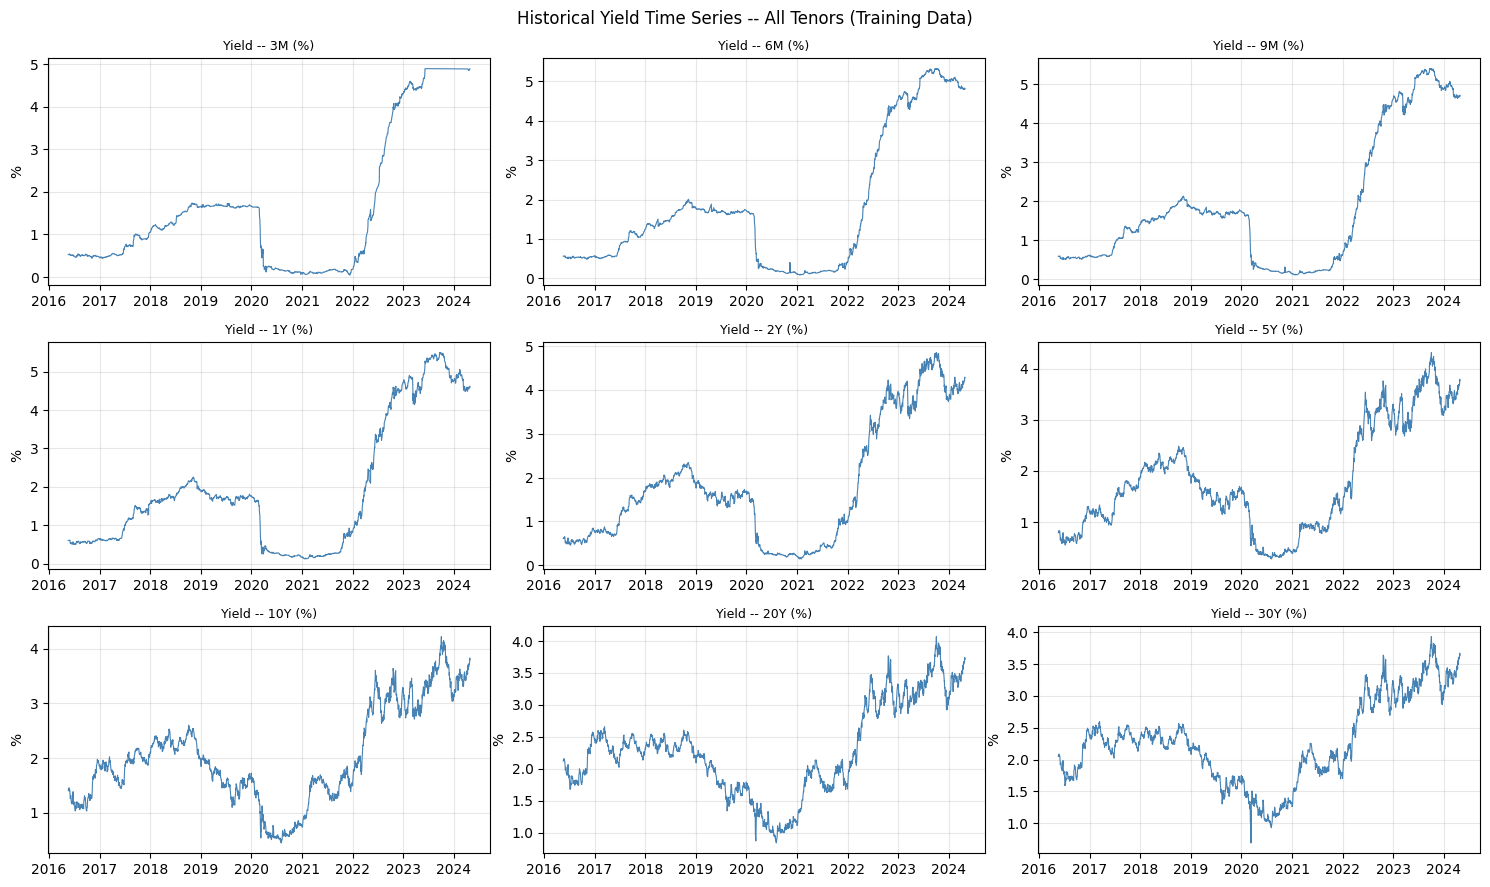

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.ravel()
for i, (col, ax) in enumerate(zip(train.columns, axes)):
    ax.plot(train.index, train[col]*100, lw=0.8, color='steelblue')
    ax.set_title(f'Yield -- {col} (%)', fontsize=9)
    ax.set_ylabel('%'); ax.grid(True, alpha=0.3)
plt.suptitle('Historical Yield Time Series -- All Tenors (Training Data)', fontsize=12)
plt.tight_layout(); plt.savefig('eda_yields.png', dpi=120, bbox_inches='tight'); plt.show()

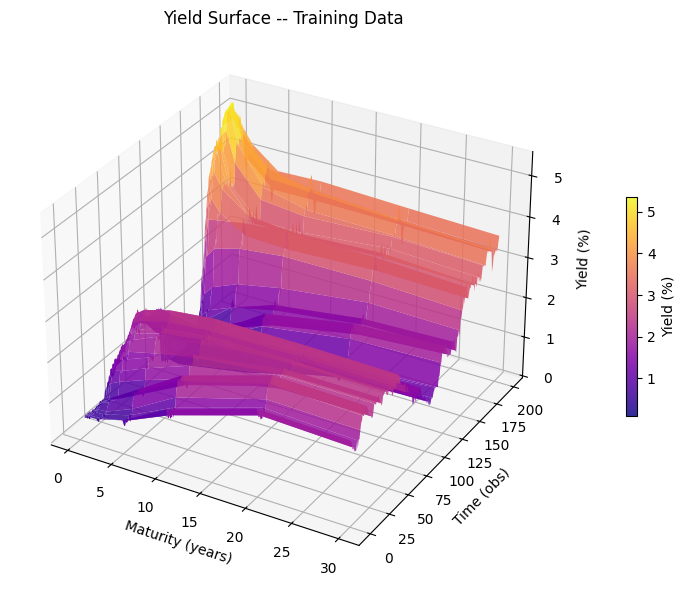

In [11]:
fig = plt.figure(figsize=(14,6))
ax  = fig.add_subplot(111, projection='3d')
sample_idx = np.linspace(0, len(train)-1, 200, dtype=int)
dates_num  = np.arange(len(sample_idx))
mats_arr   = np.array(MATURITIES)
X, Y = np.meshgrid(mats_arr, dates_num)
Z    = train.iloc[sample_idx].values * 100
surf = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.85, linewidth=0)
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Time (obs)'); ax.set_zlabel('Yield (%)')
ax.set_title('Yield Surface -- Training Data')
fig.colorbar(surf, ax=ax, shrink=0.4, label='Yield (%)')
plt.tight_layout(); plt.savefig('yield_surface.png', dpi=120, bbox_inches='tight'); plt.show()

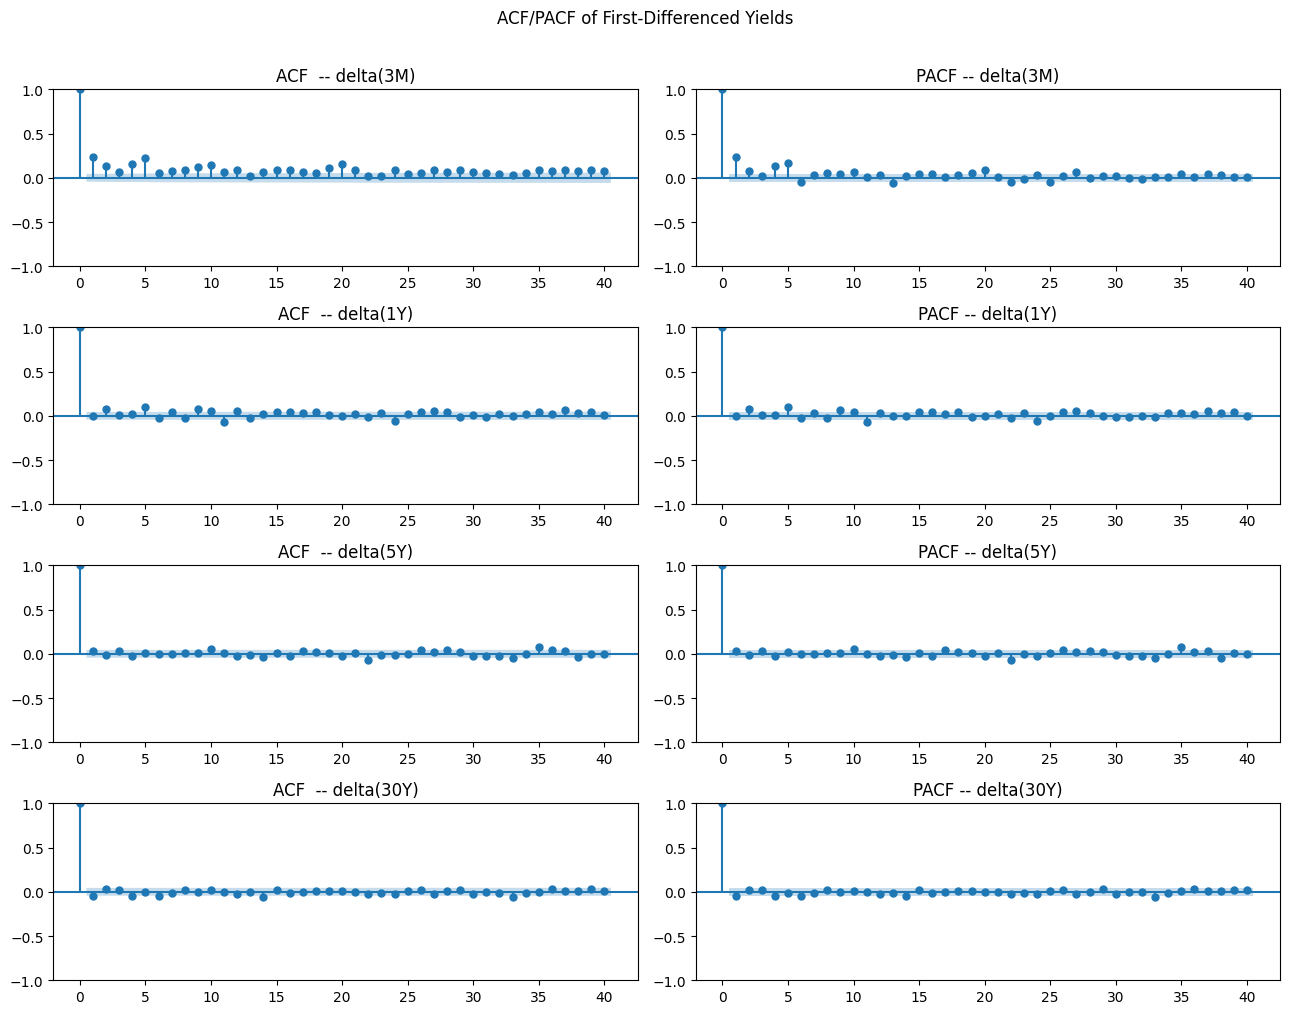

In [12]:
tenors_to_plot = ['3M','1Y','5Y','30Y']
fig, axes = plt.subplots(4, 2, figsize=(13, 10))
for i, col in enumerate(tenors_to_plot):
    diff_series = train[col].diff().dropna()
    plot_acf( diff_series, lags=40, ax=axes[i,0], title=f'ACF  -- delta({col})', alpha=0.05)
    plot_pacf(diff_series, lags=40, ax=axes[i,1], title=f'PACF -- delta({col})', alpha=0.05, method='ywm')
plt.suptitle('ACF/PACF of First-Differenced Yields', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('acf_pacf.png', dpi=120, bbox_inches='tight'); plt.show()

# Module 1: Stochastic Calculus of the CIR Model

## 1.1 Derivation from Economic Primitives

Cox, Ingersoll & Ross (1985) derive the short-rate process from a **general equilibrium production economy**. The representative agent maximises:

$$\mathbb{E}_0\!\left[\int_0^\infty e^{-\rho t} U(C_t)\,dt\right]$$

Under log utility and a square-root production variance, the equilibrium real interest rate satisfies:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t, \qquad r_0 > 0 \tag{CIR SDE}$$

- $\kappa > 0$: speed of mean-reversion  
- $\theta > 0$: long-run equilibrium rate  
- $\sigma > 0$: instantaneous volatility  
- **Feller condition**: $2\kappa\theta \geq \sigma^2$ ensures $r_t > 0$ a.s.

## 1.2 Closed-Form Moments via Ito's Lemma

Applying Ito's lemma to $f(r_t) = r_t$ and taking expectations:

$$\mathbb{E}[r_t | r_0] = \theta + (r_0 - \theta)e^{-\kappa t}$$

For the variance (apply Ito to $r_t^2$, take expectations):

$$\mathrm{Var}(r_t | r_0) = \frac{\sigma^2\theta}{2\kappa}(1-e^{-\kappa t})^2 + \frac{\sigma^2 r_0}{\kappa}e^{-\kappa t}(1-e^{-\kappa t})$$

As $t \to \infty$: $\mathbb{E}[r_\infty] = \theta$, $\mathrm{Var}(r_\infty) = \sigma^2\theta/(2\kappa)$.

## 1.3 Exact Transition Density -- Non-Central Chi-Squared

$$p(r_t | r_s) = c \cdot e^{-u-v}\left(\frac{v}{u}\right)^{q/2} I_q(2\sqrt{uv})$$

where:
$$c = \frac{2\kappa}{\sigma^2(1-e^{-\kappa\tau})},\quad u = c\,r_s e^{-\kappa\tau},\quad v = c\,r_t,\quad q = \frac{2\kappa\theta}{\sigma^2}-1$$

$I_q$ is the modified Bessel function of the first kind. Equivalently: $2c\,r_t | r_s \sim \chi^2(2q+2,\;2u)$.

## 1.4 Fokker-Planck (Kolmogorov Forward) Equation

The probability density $p(r,t)$ evolves via:

$$\frac{\partial p}{\partial t} = -\frac{\partial}{\partial r}[\kappa(\theta-r)\,p] + \frac{1}{2}\frac{\partial^2}{\partial r^2}[\sigma^2 r\,p]$$

**Stationary distribution** ($\partial p/\partial t = 0$):

$$p_\infty(r) \sim \mathrm{Gamma}\!\left(\frac{2\kappa\theta}{\sigma^2},\;\frac{\sigma^2}{2\kappa}\right)$$

## 1.5 Edgeworth Series Expansion

For moderate $t$, the non-central chi-squared density is approximated via:

$$p_X(x) \approx \frac{\phi(z)}{\sigma_X}\left[1 + \frac{\kappa_3}{6\sigma_X^3}H_3(z) + \frac{\kappa_4}{24\sigma_X^4}H_4(z) + \frac{\kappa_3^2}{72\sigma_X^6}H_6(z)\right]$$

where $z = (x-\mu_X)/\sigma_X$, $H_3(z) = z^3-3z$, $H_4 = z^4-6z^2+3$, $H_6 = z^6-15z^4+45z^2-15$, and cumulants $\kappa_3 = 8(q+1+3u)$, $\kappa_4 = 48(q+1+4u)$.

## 1.6 Bond Pricing via Feynman-Kac

The zero-coupon bond $P(t,T) = \mathbb{E}^{\mathbb{Q}}[e^{-\int_t^T r_s\,ds}|r_t]$ satisfies:

$$\frac{\partial P}{\partial t} + \kappa^*(\theta^*-r)\frac{\partial P}{\partial r} + \frac{\sigma^2 r}{2}\frac{\partial^2 P}{\partial r^2} - rP = 0, \quad P(T,T)=1$$

Closed-form solution: $P(t,T) = A(\tau)^{2\kappa\theta/\sigma^2}\,e^{-B(\tau)r_t}$

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa^*)(e^{\gamma\tau}-1)+2\gamma}, \quad A(\tau) = \frac{2\gamma\,e^{(\gamma+\kappa^*)\tau/2}}{(\gamma+\kappa^*)(e^{\gamma\tau}-1)+2\gamma}$$

with $\gamma = \sqrt{(\kappa^*)^2+2\sigma^2}$, and yield $y(\tau; r_t) = [B(\tau)r_t - \ln A(\tau)^{2\kappa\theta/\sigma^2}]/\tau$.

In [13]:
# ============================================================
# CIR BOND PRICING
# ============================================================
def cir_AB(tau, kappa, theta, sigma, lam=0.0):
    "Compute log(A^{2kt/s2}) and B for CIR bond pricing."
    tau   = np.atleast_1d(tau).astype(float)
    kstar = kappa + lam * sigma
    gamma = np.sqrt(kstar**2 + 2 * sigma**2)
    denom = (gamma + kstar) * (np.exp(gamma * tau) - 1) + 2 * gamma
    B     = 2 * (np.exp(gamma * tau) - 1) / (denom + 1e-15)
    logApow = (2 * kappa * theta / sigma**2) * np.log(
        2 * gamma * np.exp((gamma + kstar) * tau / 2) / (denom + 1e-15))
    return logApow, B

def cir_yield(tau, r0, kappa, theta, sigma, lam=0.0):
    "CIR yield y(tau; r0)."
    tau = np.atleast_1d(tau).astype(float)
    r0  = np.atleast_1d(r0).astype(float)
    if r0.ndim == 1 and tau.ndim == 1 and len(r0) != len(tau):
        # Vectorise over r0 for a single tau
        if len(tau) == 1:
            logA, B = cir_AB(tau, kappa, theta, sigma, lam)
            return (B[0] * r0 - logA[0]) / tau[0]
    logA, B = cir_AB(tau, kappa, theta, sigma, lam)
    return (B * r0 - logA) / tau

# Sanity check
p = dict(kappa=0.8, theta=0.04, sigma=0.1)
y_test = [cir_yield(np.array([t]), np.array([0.04]), **p)[0]*100 for t in MATURITIES]
print("CIR yield curve test (kappa=0.8, theta=4%, sigma=0.1):")
for m, y in zip(MAT_LABELS, y_test):
    print(f"  {m}: {y:.4f}%")

CIR yield curve test (kappa=0.8, theta=4%, sigma=0.1):
  3M: 3.9996%
  6M: 3.9988%
  9M: 3.9976%
  1Y: 3.9962%
  2Y: 3.9906%
  5Y: 3.9804%
  10Y: 3.9749%
  20Y: 3.9721%
  30Y: 3.9711%


## 1.7 MCMC Calibration -- Bayesian Posterior of $(\kappa, \theta, \sigma)$

**Bayesian framework:**

$$\pi(\kappa, \theta, \sigma \mid \mathbf{r}) \propto \mathcal{L}(\mathbf{r} \mid \kappa, \theta, \sigma) \cdot \pi_0(\kappa, \theta, \sigma)$$

**Log-likelihood** (exact non-central chi-squared transitions):

$$\log\mathcal{L} = \sum_{t=1}^{T-1} \log p(r_{t+1} \mid r_t;\,\kappa, \theta, \sigma, \Delta t)$$

**Weakly informative priors:**
$$\kappa \sim \mathrm{Gamma}(2, 1), \quad \theta \sim \mathrm{Gamma}(2, 0.05), \quad \sigma \sim \mathrm{HalfNormal}(0.3)$$

**Metropolis-Hastings** with log-space random-walk proposal (ensures positivity):
$$\log\theta^* = \log\theta^{(m)} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \delta^2)$$

Acceptance probability: $\alpha = \min\!\left(1,\;\frac{\pi(\theta^*)q(\theta^{(m)}|\theta^*)}{\pi(\theta^{(m)})q(\theta^*|\theta^{(m)})}\right)$

The Jacobian correction for the log-transform is absorbed into the proposal ratio.

In [14]:
# ============================================================
# LOG-POSTERIOR
# ============================================================
def cir_log_transition(r_next, r_curr, kappa, theta, sigma, dt):
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return -np.inf
    c  = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * dt)) + 1e-15)
    u  = c * r_curr * np.exp(-kappa * dt)
    v  = c * r_next
    df = 4 * kappa * theta / sigma**2
    nc = 2 * u
    if df <= 0 or nc < 0:
        return -np.inf
    return ncx2.logpdf(2 * v, df=df, nc=nc) + np.log(2 * c + 1e-15)

def log_prior(kappa, theta, sigma):
    return (sp_gamma.logpdf(kappa, a=2, scale=1.0) +
            sp_gamma.logpdf(theta, a=2, scale=0.05) +
            halfnorm.logpdf(sigma, scale=0.3))

def log_posterior(params, r_series, dt=1/252):
    kappa, theta, sigma = params
    if kappa<=0 or theta<=0 or sigma<=0:
        return -np.inf
    ll = sum(cir_log_transition(r_series[i+1], r_series[i], kappa, theta, sigma, dt)
             for i in range(len(r_series)-1))
    return ll + log_prior(kappa, theta, sigma)

r_train = train['3M'].dropna().values
print(f"Short-rate proxy: {len(r_train)} observations")
print(f"Mean: {r_train.mean()*100:.3f}%, Std: {r_train.std()*100:.3f}%")

Short-rate proxy: 1976 observations
Mean: 1.653%, Std: 1.629%


In [15]:
# ============================================================
# METROPOLIS-HASTINGS MCMC
# ============================================================
def metropolis_hastings(log_post, init, n_iter=10000, proposal_std=0.06, seed=42, r_series=None):
    np.random.seed(seed)
    n_params = len(init)
    samples  = np.zeros((n_iter, n_params))
    current  = np.array(init, dtype=float)
    log_p_curr = log_post(current, r_series)
    accept_count = 0

    for i in range(n_iter):
        proposal   = current * np.exp(proposal_std * np.random.randn(n_params))
        log_p_prop = log_post(proposal, r_series)
        if np.log(np.random.rand()) < log_p_prop - log_p_curr:
            current    = proposal
            log_p_curr = log_p_prop
            accept_count += 1
        samples[i] = current
        if (i+1) % 2500 == 0:
            print(f"  Iter {i+1:6d} | kappa={current[0]:.4f}  theta={current[1]*100:.3f}%"
                  f"  sigma={current[2]:.4f}  accept={accept_count/(i+1)*100:.1f}%")

    print(f"Final acceptance rate: {accept_count/n_iter*100:.2f}%")
    return samples

print("Running MCMC...")
init_params = [0.5, r_train.mean(), 0.08]
samples_raw = metropolis_hastings(log_posterior, init_params,
                                   n_iter=10000, r_series=r_train)
burn_in = 3000
samples = samples_raw[burn_in:]
kappa_s, theta_s, sigma_s = samples[:,0], samples[:,1], samples[:,2]

kappa_hat = np.median(kappa_s)
theta_hat = np.median(theta_s)
sigma_hat = np.median(sigma_s)

print(f"\\nPosterior medians:")
print(f"  kappa = {kappa_hat:.5f}  |  theta = {theta_hat*100:.4f}%  |  sigma = {sigma_hat:.5f}")
print(f"  Feller: 2*kappa*theta = {2*kappa_hat*theta_hat:.6f},  sigma^2 = {sigma_hat**2:.6f}",
      "SATISFIED" if 2*kappa_hat*theta_hat > sigma_hat**2 else "VIOLATED")
print(f"  Mean-reversion half-life: {np.log(2)/kappa_hat*252:.1f} trading days")

Running MCMC...
  Iter   2500 | kappa=0.0419  theta=6.409%  sigma=0.0428  accept=31.6%
  Iter   5000 | kappa=0.0553  theta=2.883%  sigma=0.0438  accept=31.9%
  Iter   7500 | kappa=0.0420  theta=8.109%  sigma=0.0438  accept=31.1%
  Iter  10000 | kappa=0.1404  theta=2.001%  sigma=0.0415  accept=31.3%
Final acceptance rate: 31.28%
\nPosterior medians:
  kappa = 0.04743  |  theta = 4.2914%  |  sigma = 0.04250
  Feller: 2*kappa*theta = 0.004071,  sigma^2 = 0.001806 SATISFIED
  Mean-reversion half-life: 3682.8 trading days


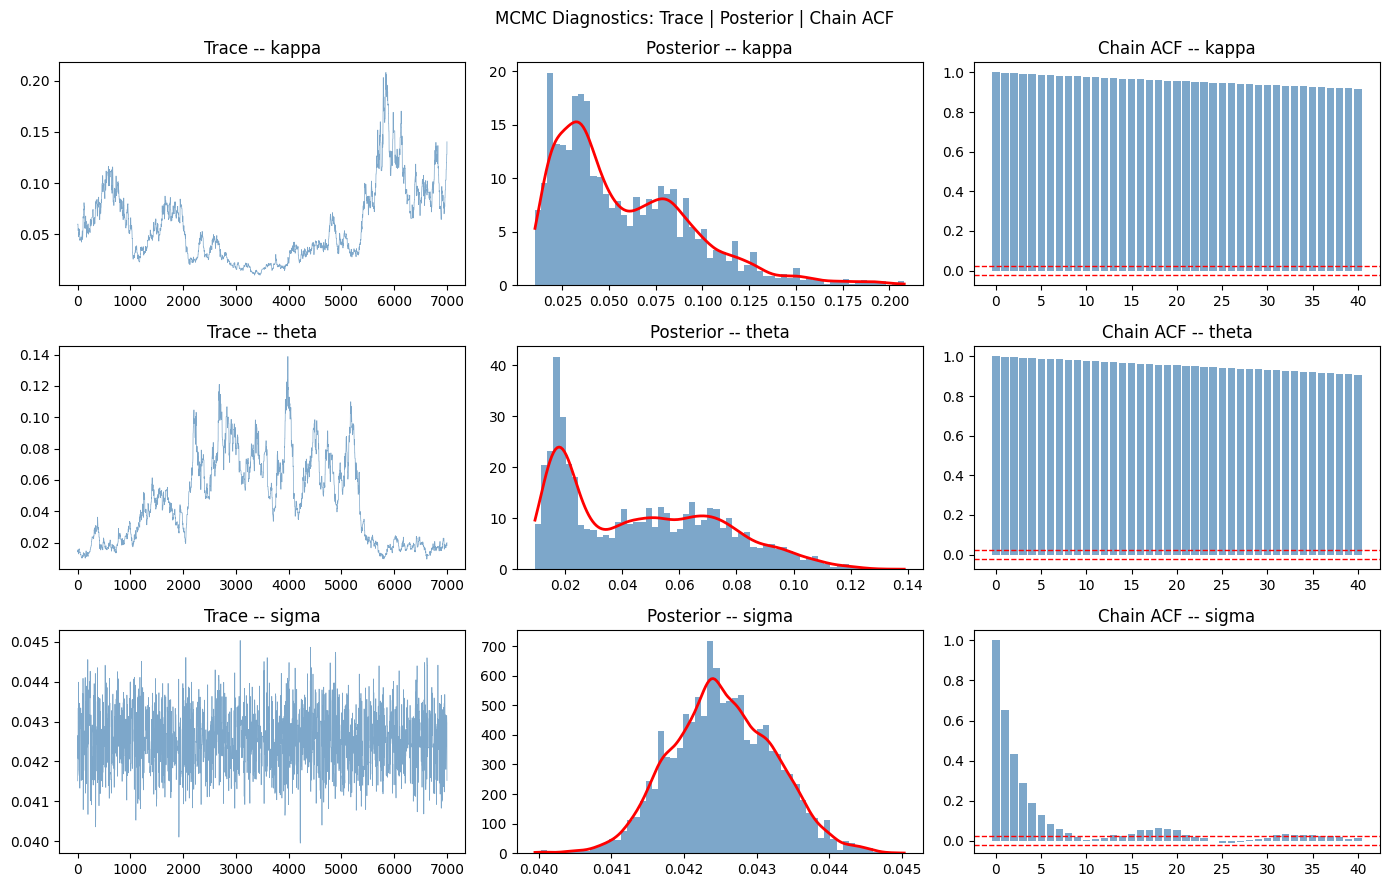

In [16]:
# ============================================================
# MCMC DIAGNOSTICS PLOT
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
param_names = ['kappa', 'theta', 'sigma']
param_data  = [kappa_s, theta_s, sigma_s]

for i, (name, data) in enumerate(zip(param_names, param_data)):
    axes[i,0].plot(data, lw=0.5, alpha=0.7, color='steelblue')
    axes[i,0].set_title(f'Trace -- {name}')
    axes[i,1].hist(data, bins=60, density=True, color='steelblue', alpha=0.7)
    x_r = np.linspace(data.min(), data.max(), 200)
    axes[i,1].plot(x_r, stats.gaussian_kde(data)(x_r), 'r-', lw=2)
    axes[i,1].set_title(f'Posterior -- {name}')
    chain_acf_vals = acf(data, nlags=40)
    axes[i,2].bar(range(len(chain_acf_vals)), chain_acf_vals, color='steelblue', alpha=0.7)
    axes[i,2].axhline(1.96/np.sqrt(len(data)), color='r', ls='--', lw=1)
    axes[i,2].axhline(-1.96/np.sqrt(len(data)), color='r', ls='--', lw=1)
    axes[i,2].set_title(f'Chain ACF -- {name}')

plt.suptitle('MCMC Diagnostics: Trace | Posterior | Chain ACF', fontsize=12)
plt.tight_layout(); plt.savefig('mcmc_diagnostics.png', dpi=120, bbox_inches='tight'); plt.show()

In [21]:
# ============================================================
# FOKKER-PLANCK PDE (Crank-Nicolson)
# ============================================================
def fokker_planck_cn(kappa, theta, sigma, r_init, n_grid=300, t_end=1.5, n_steps=300):
    r_max = max(theta*6, r_init*5, 0.3)
    r     = np.linspace(1e-6, r_max, n_grid)
    dr    = r[1] - r[0]
    dt    = t_end / n_steps
    sig0  = sigma * np.sqrt(r_init/(2*kappa)+1e-6) + 1e-4
    p     = np.exp(-0.5*((r-r_init)/sig0)**2)
    p /= trapz(p, r)

    mu_r   = kappa*(theta - r)
    diff_r = 0.5*sigma**2*r

    def L_matrix():
        N = n_grid
        d, u, lo = np.zeros(N), np.zeros(N-1), np.zeros(N-1)
        for i in range(1, N-1):
            Dp = diff_r[i+1]; Dm = diff_r[i-1]; Di = diff_r[i]
            dcu = (Dp+Di)/(2*dr**2); dcl = (Di+Dm)/(2*dr**2)
            d[i]   -= (dcu+dcl); u[i] += dcu; lo[i-1] += dcl
            if mu_r[i] >= 0:
                d[i] -= mu_r[i]/dr; lo[i-1] += mu_r[i]/dr
            else:
                d[i] += mu_r[i]/dr; u[i]    -= mu_r[i]/dr
        return np.diag(d) + np.diag(u,1) + np.diag(lo,-1)

    L = L_matrix()
    I = np.eye(n_grid)
    A = I - 0.5*dt*L
    B = I + 0.5*dt*L

    snaps, snap_t = [p.copy()], [0.0]
    every = max(1, n_steps//40)
    for step in range(n_steps):
        rhs = B @ p; rhs[0] = 0; rhs[-1] = 0
        p_new = np.linalg.solve(A, rhs)
        p_new = np.maximum(p_new, 0)
        norm  = trapz(p_new, r)
        if norm > 1e-10: p_new /= norm
        p = p_new
        if (step+1) % every == 0:
            snaps.append(p.copy()); snap_t.append((step+1)*dt)

    return r, np.array(snap_t), np.array(snaps)

print("Solving Fokker-Planck PDE (Crank-Nicolson)...")
r0_fp = r_train[0]
r_grid, snap_times, density_snaps = fokker_planck_cn(
    kappa_hat, theta_hat, sigma_hat, r0_fp)
print(f"Done. {len(snap_times)} snapshots on {len(r_grid)}-point grid.")

Solving Fokker-Planck PDE (Crank-Nicolson)...
Done. 43 snapshots on 300-point grid.


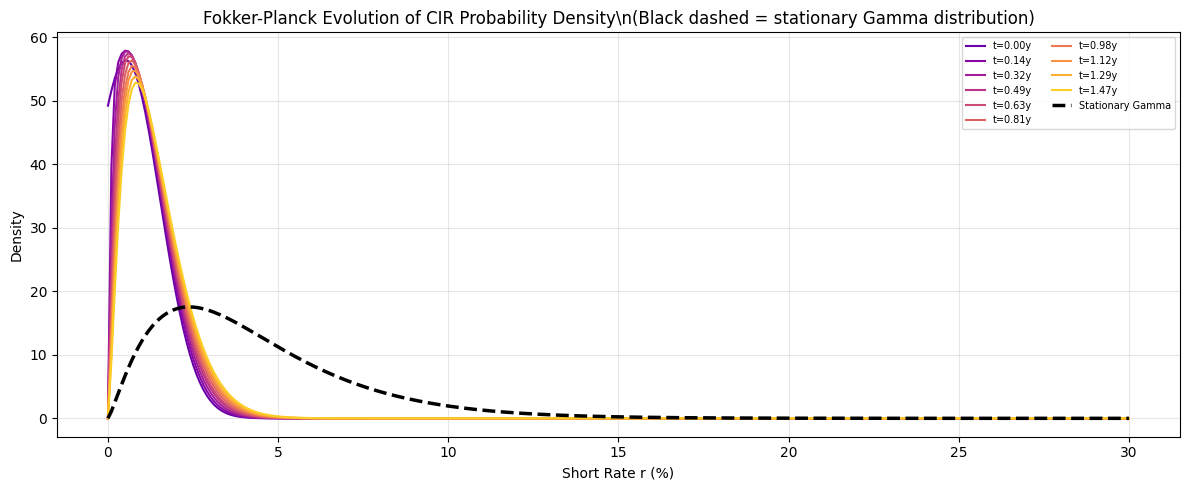

In [22]:
# ============================================================
# DENSITY EVOLUTION PLOT + STATIONARY GAMMA
# ============================================================
from matplotlib import cm as mpl_cm

fig, ax = plt.subplots(figsize=(12,5))
n_show  = 10
indices = np.linspace(0, len(snap_times)-1, n_show, dtype=int)
colors  = mpl_cm.plasma(np.linspace(0.2, 0.9, n_show))

for k, idx in enumerate(indices):
    ax.plot(r_grid*100, density_snaps[idx], color=colors[k], lw=1.5,
            label=f't={snap_times[idx]:.2f}y')

alpha_stat = 2*kappa_hat*theta_hat/sigma_hat**2
beta_stat  = sigma_hat**2/(2*kappa_hat)
p_stat = sp_gamma.pdf(r_grid, a=alpha_stat, scale=beta_stat)
ax.plot(r_grid*100, p_stat, 'k--', lw=2.5, label='Stationary Gamma')

ax.set_xlabel('Short Rate r (%)'); ax.set_ylabel('Density')
ax.set_title('Fokker-Planck Evolution of CIR Probability Density\\n(Black dashed = stationary Gamma distribution)')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fokker_planck_density.png', dpi=120, bbox_inches='tight'); plt.show()

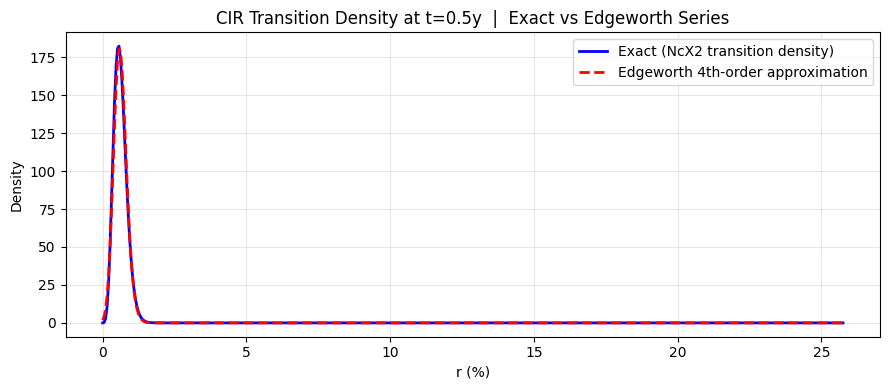

In [23]:
# ============================================================
# EDGEWORTH EXPANSION vs EXACT NcX2
# ============================================================
def edgeworth_density(x, mean_x, var_x, kappa3, kappa4):
    sigma_x = np.sqrt(var_x)
    z = (x - mean_x) / sigma_x
    phi_z = stats.norm.pdf(z)
    H3 = z**3 - 3*z
    H4 = z**4 - 6*z**2 + 3
    H6 = z**6 - 15*z**4 + 45*z**2 - 15
    corr = 1 + kappa3/(6*sigma_x**3)*H3 + kappa4/(24*sigma_x**4)*H4 + kappa3**2/(72*sigma_x**6)*H6
    return phi_z * corr / sigma_x

dt_fp = 0.5
c     = 2*kappa_hat / (sigma_hat**2*(1-np.exp(-kappa_hat*dt_fp)) + 1e-15)
u     = c * r0_fp * np.exp(-kappa_hat*dt_fp)
q_cir = 2*kappa_hat*theta_hat/sigma_hat**2 - 1
mu_X  = 2*(q_cir+1) + 2*u
var_X = 2*(2*(q_cir+1) + 4*u)
k3    = 8*(q_cir+1+3*u)
k4    = 48*(q_cir+1+4*u)

r_plot = np.linspace(1e-5, theta_hat*6, 500)
x_vals = 2 * c * r_plot
exact_dens = ncx2.pdf(x_vals, df=2*(q_cir+1), nc=2*u) * (2*c)
ew_dens    = np.maximum(edgeworth_density(x_vals, mu_X, var_X, k3, k4) * (2*c), 0)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(r_plot*100, exact_dens, 'b-',  lw=2, label='Exact (NcX2 transition density)')
ax.plot(r_plot*100, ew_dens,    'r--', lw=2, label='Edgeworth 4th-order approximation')
ax.set_xlabel('r (%)'); ax.set_ylabel('Density')
ax.set_title(f'CIR Transition Density at t=0.5y  |  Exact vs Edgeworth Series')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('edgeworth_vs_exact.png', dpi=120, bbox_inches='tight'); plt.show()

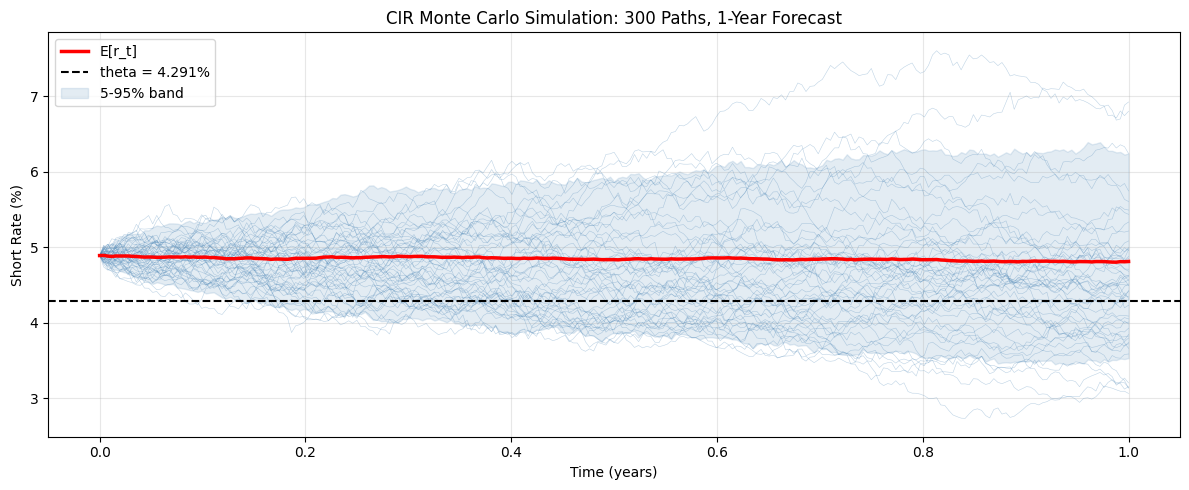

In [24]:
# ============================================================
# MONTE CARLO SIMULATION
# ============================================================
def simulate_cir(kappa, theta, sigma, r0, n_paths=300, n_steps=252, dt=1/252, seed=0):
    np.random.seed(seed)
    r  = np.zeros((n_steps+1, n_paths)); r[0] = r0
    dW = np.random.randn(n_steps, n_paths) * np.sqrt(dt)
    for t in range(n_steps):
        rp = np.maximum(r[t], 0)
        r[t+1] = np.maximum(r[t] + kappa*(theta-rp)*dt + sigma*np.sqrt(rp)*dW[t], 0)
    return r

r_paths = simulate_cir(kappa_hat, theta_hat, sigma_hat, r0=r_train[-1])
t_axis  = np.linspace(0, 1, r_paths.shape[0])

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(t_axis, r_paths[:,:50]*100, lw=0.4, alpha=0.35, color='steelblue')
ax.plot(t_axis, r_paths.mean(axis=1)*100, 'r-', lw=2.5, label='E[r_t]')
ax.axhline(theta_hat*100, color='k', ls='--', lw=1.5, label=f'theta = {theta_hat*100:.3f}%')
ax.fill_between(t_axis,
                np.percentile(r_paths,5,axis=1)*100,
                np.percentile(r_paths,95,axis=1)*100,
                alpha=0.15, color='steelblue', label='5-95% band')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Short Rate (%)')
ax.set_title('CIR Monte Carlo Simulation: 300 Paths, 1-Year Forecast')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('mc_paths.png', dpi=120, bbox_inches='tight'); plt.show()

# Module 2: Financial Econometrics of the Yield Curve

## 2.1 Euler-Maruyama Discretisation -> ARMA-GARCH Connection

The CIR SDE discretised with step $\Delta t$ via Euler-Maruyama:

$$\Delta r_t = \underbrace{\kappa\theta\Delta t}_{\mu} - \underbrace{\kappa\Delta t}_{\phi} r_t + \sigma\sqrt{r_t\Delta t}\,\varepsilon_{t+1}$$

This is an **AR(1) in levels** with conditional variance $\mathrm{Var}(\Delta r_t|r_t) = \sigma^2 r_t\Delta t$.

**GARCH(1,1) model:**
$$h_t = \omega + \alpha_1\varepsilon_{t-1}^2 + \beta_1 h_{t-1}$$

**GJR-GARCH** (captures leverage/asymmetry):
$$h_t = \omega + \alpha_1\varepsilon_{t-1}^2 + \gamma_1\varepsilon_{t-1}^2\mathbf{1}_{\varepsilon_{t-1}<0} + \beta_1 h_{t-1}$$

**EGARCH** (log-linearised CIR variance equation -- the Brigo-Mercurio connection):
$$\log h_t = \omega + \alpha_1(|\tilde\varepsilon_{t-1}| - \mathbb{E}[|\tilde\varepsilon|]) + \gamma_1\tilde\varepsilon_{t-1}\mathbf{1}_{\tilde\varepsilon_{t-1}<0} + \beta_1\log h_{t-1}$$

**Key result**: The AR(1) coefficient $a_1 \approx 1 - \kappa\Delta t$ gives $\hat\kappa = (1-a_1)/\Delta t$; the intercept $a_0 \approx \kappa\theta\Delta t$ gives $\hat\theta = a_0/(a_0 + a_1 - 1) = a_0/(\kappa\Delta t)$.

## 2.2 Nelson-Siegel Decomposition

$$y(t,\tau) = \beta_0 + \beta_1\frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_2\!\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right)$$

- $\beta_0$: level factor (long-run rate)  
- $\beta_1$: slope factor ($\approx$ short minus long rate)  
- $\beta_2$: curvature/hump factor

## 2.3 Johansen Cointegration Test

For yield vector $\mathbf{y}_t$, the VECM is:

$$\Delta\mathbf{y}_t = \Pi\mathbf{y}_{t-1} + \sum_{j=1}^{p-1}\Gamma_j\Delta\mathbf{y}_{t-j} + \boldsymbol\varepsilon_t, \quad \Pi = \alpha\beta'$$

The **trace statistic** $\lambda_\mathrm{trace} = -T\sum_{i=r+1}^k\ln(1-\hat\lambda_i)$ tests $H_0: \mathrm{rank}(\Pi)\leq r$.

## 2.4 Hypothesis Tests Applied

| Test | Null Hypothesis | Statistic |
|------|----------------|-----------|
| ADF | Unit root (non-stationary) | t-stat on $\Delta y_{t-1}$ coefficient |
| Ljung-Box | No autocorrelation up to lag $h$ | $Q = T(T+2)\sum_{k=1}^h\hat\rho_k^2/(T-k)$ |
| ARCH-LM | No ARCH effects | $TR^2$ from regressing $\hat\varepsilon_t^2$ on lags |
| Johansen trace | At most $r$ cointegrating vectors | $-T\sum\ln(1-\hat\lambda_i)$ |

In [25]:
# ============================================================
# AR(1)-GARCH(1,1) and EGARCH on 3M yield changes
# ============================================================
dr_train = train['3M'].diff().dropna() * 100  # in percentage points

# GARCH(1,1)
am_garch = arch_model(dr_train, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal')
res_garch = am_garch.fit(disp='off')
print("=== AR(1)-GARCH(1,1) ===")
print(res_garch.summary())

=== AR(1)-GARCH(1,1) ===
                           AR - GARCH Model Results                           
Dep. Variable:                     3M   R-squared:                       0.052
Mean Model:                        AR   Adj. R-squared:                  0.052
Vol Model:                      GARCH   Log-Likelihood:                5704.46
Distribution:                  Normal   AIC:                          -11398.9
Method:            Maximum Likelihood   BIC:                          -11371.0
                                        No. Observations:                 1974
Date:                Fri, Jun 05 2026   Df Residuals:                     1972
Time:                        01:55:26   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const      9.1893e-05  4.862e-

In [26]:
# EGARCH
am_eg = arch_model(dr_train, mean='AR', lags=1, vol='EGARCH', p=1, o=1, q=1, dist='normal')
res_eg = am_eg.fit(disp='off')
print("=== AR(1)-EGARCH(1,1,1) ===")
print(res_eg.summary())

=== AR(1)-EGARCH(1,1,1) ===
                          AR - EGARCH Model Results                           
Dep. Variable:                     3M   R-squared:                      -0.088
Mean Model:                        AR   Adj. R-squared:                 -0.088
Vol Model:                     EGARCH   Log-Likelihood:                6440.41
Distribution:                  Normal   AIC:                          -12868.8
Method:            Maximum Likelihood   BIC:                          -12835.3
                                        No. Observations:                 1974
Date:                Fri, Jun 05 2026   Df Residuals:                     1972
Time:                        01:55:54   Df Model:                            2
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const      -1.0757e-05  

=== CIR parameter recovery from GARCH mean equation ===
  kappa (GARCH) = 191.7217  |  kappa (MCMC) = 0.0474
  theta (GARCH) = 0.0121%  |  theta (MCMC) = 4.2914%



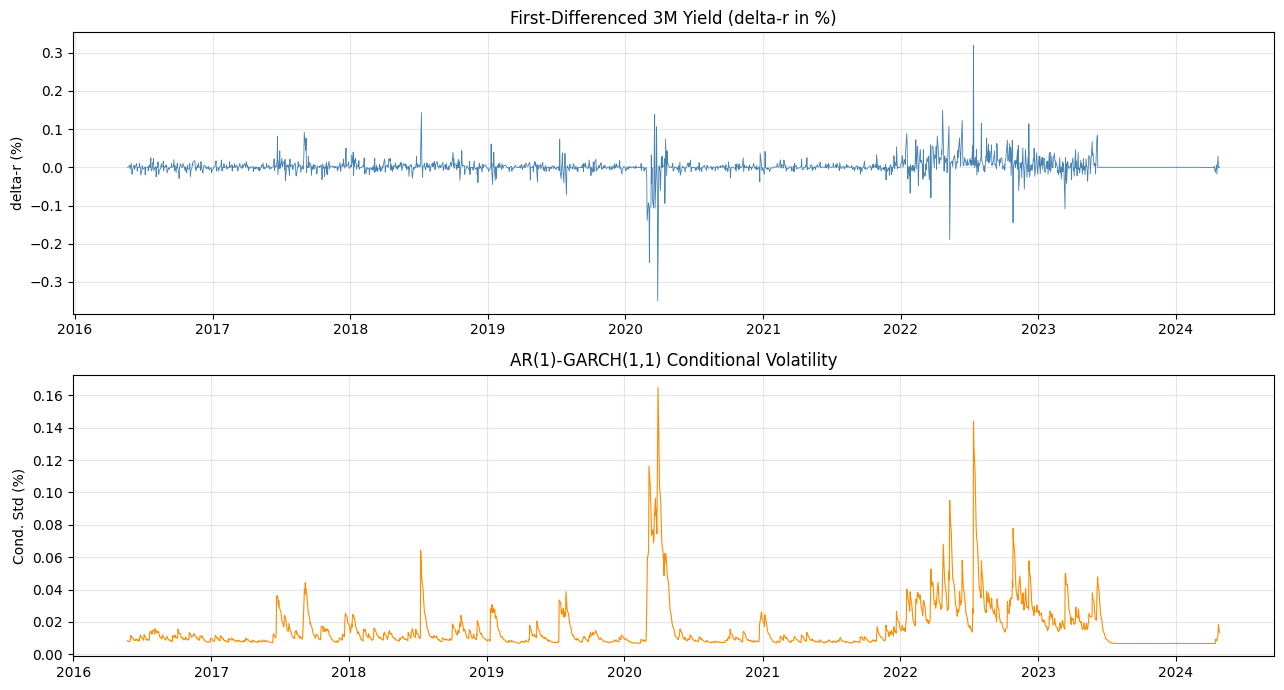

In [27]:
# CIR PARAMETER RECOVERY FROM GARCH MEAN EQUATION

dt = 1/252
a0 = res_garch.params.get('Const', res_garch.params.iloc[0])
a1 = res_garch.params.get('ar.L1', res_garch.params.iloc[1])

kappa_garch = (1 - a1) / dt
theta_garch = a0 / (kappa_garch * dt) if kappa_garch != 0 else np.nan

print("=== CIR parameter recovery from GARCH mean equation ===")
print(f"  kappa (GARCH) = {kappa_garch:.4f}  |  kappa (MCMC) = {kappa_hat:.4f}")
print(f"  theta (GARCH) = {theta_garch*100:.4f}%  |  theta (MCMC) = {theta_hat*100:.4f}%")
print()

# Conditional volatility plot
fig, axes = plt.subplots(2, 1, figsize=(13,7))
axes[0].plot(dr_train.index, dr_train, lw=0.6, color='steelblue')
axes[0].set_title('First-Differenced 3M Yield (delta-r in %)')
axes[0].set_ylabel('delta-r (%)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(res_garch.conditional_volatility.index,
             res_garch.conditional_volatility, lw=0.8, color='darkorange')
axes[1].set_title('AR(1)-GARCH(1,1) Conditional Volatility')
axes[1].set_ylabel('Cond. Std (%)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('garch_cond_vol.png', dpi=120, bbox_inches='tight'); plt.show()

In [28]:
# JOHANSEN COINTEGRATION TEST

yc   = train.dropna()
jres = coint_johansen(yc, det_order=0, k_ar_diff=2)
print("=== Johansen Cointegration Test ===")
print(f"{'H0: rank <= r':<20} {'Trace Stat':>12} {'5% CV':>10} {'Reject?':>10}")
print("-"*56)
for r_idx, (ts, cv) in enumerate(zip(jres.lr1, jres.cvt[:,1])):
    reject = "YES" if ts > cv else "no"
    print(f"  r <= {r_idx:<15} {ts:>12.4f} {cv:>10.4f} {reject:>10}")
print(f"\\nResult: {np.sum(jres.lr1 > jres.cvt[:,1])} cointegrating vectors")
print("Consistent with CIR single-factor model structure.")

=== Johansen Cointegration Test ===
H0: rank <= r          Trace Stat      5% CV    Reject?
--------------------------------------------------------
  r <= 0                   530.5165   197.3772        YES
  r <= 1                   311.9480   159.5290        YES
  r <= 2                   206.8468   125.6185        YES
  r <= 3                   117.5785    95.7542        YES
  r <= 4                    68.5800    69.8189         no
  r <= 5                    32.5409    47.8545         no
  r <= 6                    19.0378    29.7961         no
  r <= 7                     8.8010    15.4943         no
  r <= 8                     0.9234     3.8415         no
\nResult: 4 cointegrating vectors
Consistent with CIR single-factor model structure.


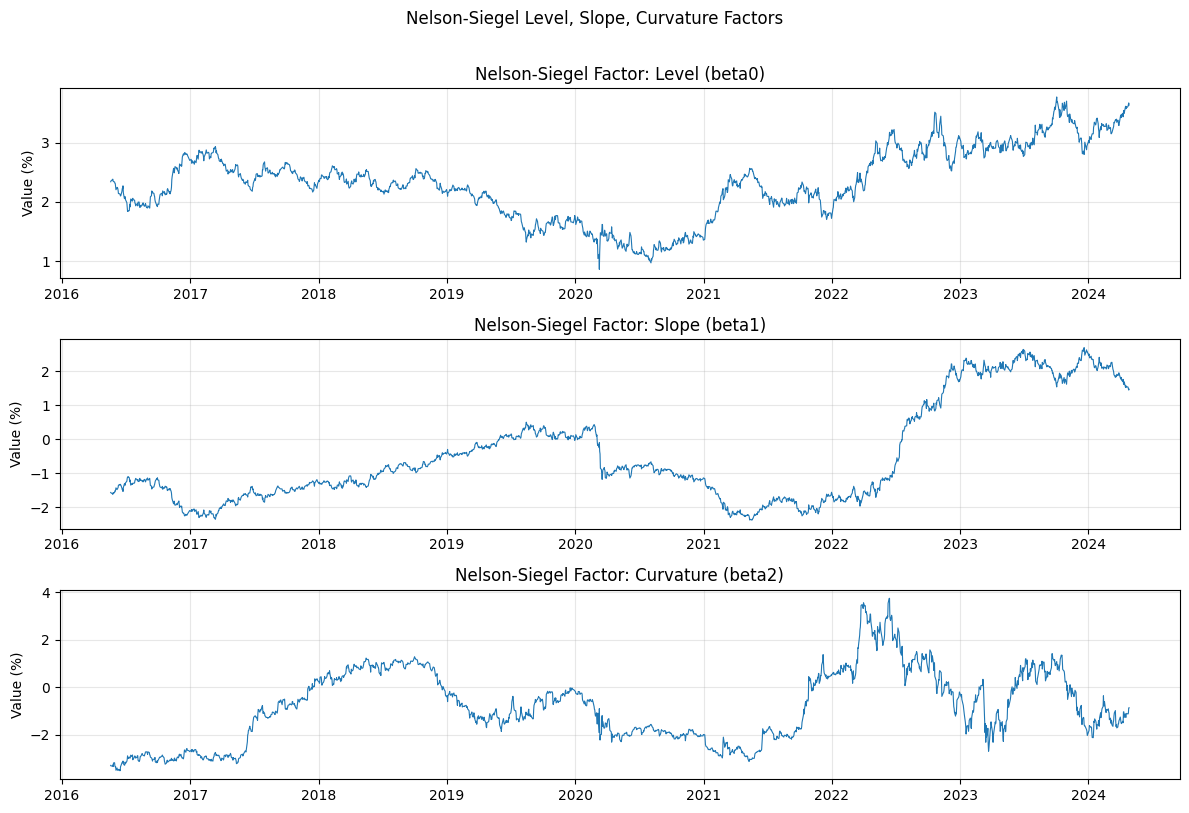

In [29]:
# NELSON-SIEGEL DECOMPOSITION

def nelson_siegel_matrix(tau, lam=0.6):
    return np.column_stack([
        np.ones(len(tau)),
        (1-np.exp(-lam*tau))/(lam*tau),
        (1-np.exp(-lam*tau))/(lam*tau) - np.exp(-lam*tau)
    ])

tau_arr = np.array(MATURITIES)
def fit_ns(yields_row, lam=0.6):
    X = nelson_siegel_matrix(tau_arr, lam)
    return np.linalg.lstsq(X, yields_row, rcond=None)[0]

ns_betas = np.array([fit_ns(train.iloc[i].values) for i in range(len(train))])
beta_df  = pd.DataFrame(ns_betas, index=train.index,
                         columns=['Level (beta0)', 'Slope (beta1)', 'Curvature (beta2)'])

fig, axes = plt.subplots(3, 1, figsize=(12,8))
for i, col in enumerate(beta_df.columns):
    axes[i].plot(beta_df.index, beta_df[col]*100, lw=0.8)
    axes[i].set_title(f'Nelson-Siegel Factor: {col}')
    axes[i].set_ylabel('Value (%)'); axes[i].grid(True, alpha=0.3)
plt.suptitle('Nelson-Siegel Level, Slope, Curvature Factors', y=1.01)
plt.tight_layout(); plt.savefig('ns_factors.png', dpi=120, bbox_inches='tight'); plt.show()

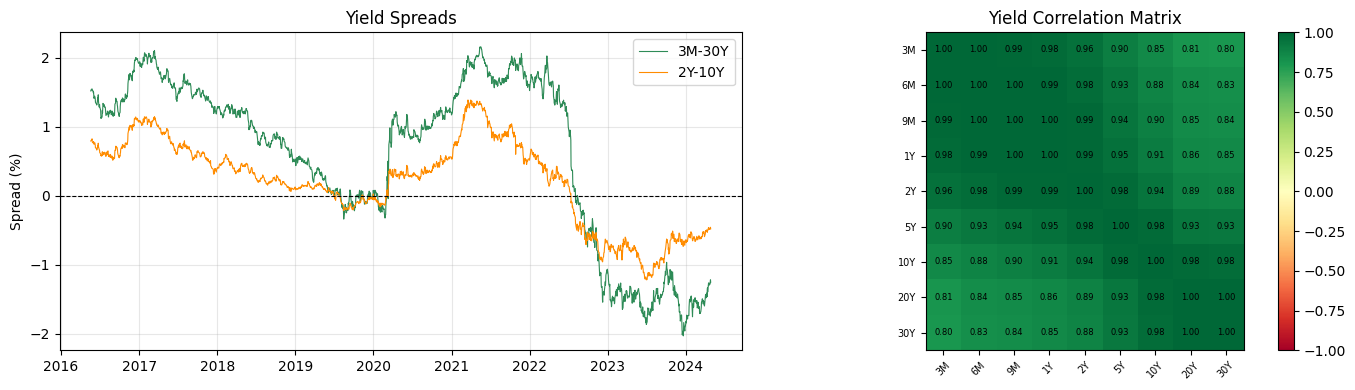

In [30]:
# YIELD SPREAD ANALYSIS + CORRELATION HEATMAP

spread_3m_30y = (train['30Y'] - train['3M']) * 100
spread_2y_10y = (train['10Y'] - train['2Y']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(train.index, spread_3m_30y, lw=0.8, color='seagreen', label='3M-30Y')
axes[0].plot(train.index, spread_2y_10y, lw=0.8, color='darkorange', label='2Y-10Y')
axes[0].axhline(0, ls='--', color='k', lw=0.8)
axes[0].set_title('Yield Spreads'); axes[0].set_ylabel('Spread (%)');
axes[0].legend(); axes[0].grid(True, alpha=0.3)

corr = train.corr()
im   = axes[1].imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr))); axes[1].set_xticklabels(corr.columns, rotation=45, fontsize=7)
axes[1].set_yticks(range(len(corr))); axes[1].set_yticklabels(corr.columns, fontsize=7)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
axes[1].set_title('Yield Correlation Matrix')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.savefig('spreads_corr.png', dpi=120, bbox_inches='tight'); plt.show()

# Module 3: Statistical Learning -- Splines, Gradient Boosting & Random Forest

## 3.1 The Regression Problem

Given the CIR model, yields are:

$$y(\tau; r_t) = \frac{B(\tau)r_t - \ln A(\tau)^{2\kappa\theta/\sigma^2}}{\tau}$$

This is **linear in $r_t$** but nonlinear in $\tau$. The ML regression problem:

$$y_{\tau,t} = f(\tau, r_{3M,t}) + \varepsilon_t$$

## 3.2 Cubic B-Spline Regression

A **B-spline basis** of degree $d$ with knots $\{\xi_k\}$:

$$f(\tau) = \sum_{j} \beta_j B_{j,d}(\tau)$$

where $B_{j,d}$ are the B-spline basis functions defined by the Cox-de Boor recursion:

$$B_{j,0}(\tau) = \mathbf{1}[\xi_j \leq \tau < \xi_{j+1}]$$
$$B_{j,k}(\tau) = \frac{\tau-\xi_j}{\xi_{j+k}-\xi_j}B_{j,k-1}(\tau) + \frac{\xi_{j+k+1}-\tau}{\xi_{j+k+1}-\xi_{j+1}}B_{j+1,k-1}(\tau)$$

**Ridge-penalised (smoothing spline)**: $\min_\beta \|\mathbf{y}-\mathbf{B}\beta\|^2 + \lambda\beta'\Omega\beta$.

## 3.3 Why Trees Approximate CIR -- Universal Approximation via Histograms

**Lemma**: The CIR yield $y(\tau; r) = [B(\tau)r - \ln A(\tau)^{2\kappa\theta/\sigma^2}]/\tau$ is Lipschitz in $(\tau, r)$ on any compact domain.

**Proof sketch**: $B(\tau)$ and $A(\tau)$ are smooth and bounded; $\partial B/\partial\tau$ and $\partial A/\partial\tau$ are bounded. Therefore $y$ has bounded partial derivatives, hence is Lipschitz.

**Theorem (Stone 1977)**: For any Lipschitz function $f: [0,T]\times[0,R] \to \mathbb{R}$ and $\varepsilon > 0$, there exists a piecewise-constant function $g$ (expressible as a regression tree) such that $\sup_{(\tau,r)} |f(\tau,r) - g(\tau,r)| < \varepsilon$.

**Gradient Boosting** (Friedman 2001) -- stagewise additive model:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta\,h_m(\mathbf{x}), \quad h_m = \arg\min_h \sum_i\left[\tilde{r}_i^{(m)} - h(\mathbf{x}_i)\right]^2$$

where $\tilde{r}_i^{(m)} = y_i - F_{m-1}(\mathbf{x}_i)$ (MSE loss pseudo-residuals). Learning rate $\eta$ and tree depth control bias-variance.

**Random Forest** bias-variance decomposition:

$$\mathbb{E}[(\hat f_{RF} - f)^2] = \mathrm{Bias}^2[f] + \rho\sigma_T^2 + \frac{1-\rho}{B}\sigma_T^2$$

where $\rho$ = pairwise tree correlation, $\sigma_T^2$ = single-tree variance. As $B\to\infty$: error $\to \mathrm{Bias}^2 + \rho\sigma_T^2$.

## 3.4 CIR++ Extension

Brigo & Mercurio's **CIR++** adds a deterministic shift to fit the initial term structure exactly:

$$r_t^{++} = r_t^{CIR} + \phi(t)$$

$$\phi(t) = f^M(0,t) - f^{CIR}(0,t;\,\kappa,\theta,\sigma)$$

where $f^M$ is the observed market instantaneous forward rate. In practice, for discrete maturities, we estimate $\phi(\tau)$ as the mean in-sample residual: $\hat\phi(\tau) = \frac{1}{T}\sum_t [y_\tau^{actual} - y_\tau^{CIR}]$.

In [31]:
# FEATURE ENGINEERING

def cir_features(r3m, tau, kappa, theta, sigma):
    logA, B = cir_AB(np.array([tau]), kappa, theta, sigma)
    theory_y = float(r3m * B[0] - logA[0]) / tau
    return [r3m, tau, tau**2, np.log(tau), np.sqrt(tau),
            float(B[0]), float(logA[0]), r3m*float(B[0]), theory_y]

FEAT_NAMES = ['r3m','tau','tau2','log_tau','sqrt_tau','B_tau','logA_tau','r_B','theory_y']
MATS_ML    = [0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
MATS_LABS  = ['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

def build_panel(df, mats, mat_labels, kappa, theta, sigma):
    rows = []
    for date in df.index:
        r = df.loc[date, '3M']
        for col, tau in zip(mat_labels, mats):
            if col not in df.columns:
                continue
            feat = cir_features(r, tau, kappa, theta, sigma)
            rows.append(feat + [df.loc[date, col]])
    return pd.DataFrame(rows, columns=FEAT_NAMES + ['y_actual'])

panel_train = build_panel(train, MATS_ML, MATS_LABS, kappa_hat, theta_hat, sigma_hat)
print(f"Panel shape: {panel_train.shape}")
print(panel_train.head(3))

Panel shape: (15808, 10)
        r3m   tau    tau2   log_tau  sqrt_tau     B_tau  logA_tau       r_B  \
0  0.005283  0.50  0.2500 -0.693147  0.707107  0.494081 -0.000252  0.002610   
1  0.005283  0.75  0.5625 -0.287682  0.866025  0.736695 -0.000566  0.003892   
2  0.005283  1.00  1.0000  0.000000  1.000000  0.976369 -0.001002  0.005158   

   theory_y  y_actual  
0  0.005725  0.005640  
1  0.005943  0.005846  
2  0.006160  0.006051  


In [32]:
# SPLINE MODEL (per-maturity)

spline_preds = {}
for col, tau in zip(MATS_LABS, MATS_ML):
    if col not in train.columns:
        continue
    X_tr = train['3M'].values.reshape(-1, 1)
    y_tr = train[col].values
    pipe = Pipeline([
        ('spline', SplineTransformer(degree=3, n_knots=8, include_bias=True)),
        ('ridge',  Ridge(alpha=0.01))
    ])
    pipe.fit(X_tr, y_tr)
    spline_preds[col] = pipe.predict(test_3m['3M'].values.reshape(-1, 1))

print("Spline predictions computed for:", list(spline_preds.keys()))

Spline predictions computed for: ['6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']


In [33]:
# GRADIENT BOOSTING MODEL

print("Training Gradient Boosting models...")
gb_models = {}
gb_preds  = {}

for col, tau in zip(MATS_LABS, MATS_ML):
    if col not in train.columns:
        continue
    X_tr = np.array([cir_features(r, tau, kappa_hat, theta_hat, sigma_hat)
                     for r in train['3M'].values])
    y_tr = train[col].values
    gb = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                    learning_rate=0.05, subsample=0.8,
                                    min_samples_leaf=5, random_state=42)
    gb.fit(X_tr, y_tr)
    gb_models[col] = gb
    X_te = np.array([cir_features(r, tau, kappa_hat, theta_hat, sigma_hat)
                     for r in test_3m['3M'].values])
    gb_preds[col] = gb.predict(X_te)

print("Done. Models trained:", list(gb_models.keys()))

Training Gradient Boosting models...
Done. Models trained: ['6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']


In [34]:
# RANDOM FOREST MODEL

print("Training Random Forest models...")
rf_models = {}
rf_preds  = {}

for col, tau in zip(MATS_LABS, MATS_ML):
    if col not in train.columns:
        continue
    X_tr = np.array([cir_features(r, tau, kappa_hat, theta_hat, sigma_hat)
                     for r in train['3M'].values])
    y_tr = train[col].values
    rf = RandomForestRegressor(n_estimators=300, max_depth=8,
                                min_samples_leaf=5, max_features='sqrt',
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_models[col] = rf
    X_te = np.array([cir_features(r, tau, kappa_hat, theta_hat, sigma_hat)
                     for r in test_3m['3M'].values])
    rf_preds[col] = rf.predict(X_te)

print("Done.")

Training Random Forest models...
Done.


In [35]:
# CIR BASELINE + CIR++ PREDICTIONS

cir_preds = {}
for col, tau in zip(MATS_LABS, MATS_ML):
    cir_preds[col] = cir_yield(np.array([tau]), test_3m['3M'].values,
                                kappa_hat, theta_hat, sigma_hat)

# CIR++ shift
phi = {}
for col, tau in zip(MATS_LABS, MATS_ML):
    if col not in train.columns:
        continue
    cir_train_pred = cir_yield(np.array([tau]), train['3M'].values,
                                kappa_hat, theta_hat, sigma_hat)
    phi[col] = (train[col].values - cir_train_pred).mean()

cir_pp_preds = {col: cir_preds[col] + phi.get(col, 0) for col in MATS_LABS}

print("CIR++ shift (phi) per maturity:")
for col in MATS_LABS:
    if col in phi:
        print(f"  {col}: {phi[col]*10000:+.1f} bps")

CIR++ shift (phi) per maturity:
  6M: +10.5 bps
  9M: +15.4 bps
  1Y: +20.3 bps
  2Y: +3.4 bps
  5Y: -12.0 bps
  10Y: -12.7 bps
  20Y: -17.5 bps
  30Y: -39.2 bps


In [36]:
# EVALUATION

def evaluate(preds, actuals, mats_labs):
    r2s, rmses = [], []
    for col in mats_labs:
        if col not in actuals.columns or col not in preds:
            continue
        y_true = actuals[col].values
        y_pred = preds[col]
        r2s.append(r2_score(y_true, y_pred))
        rmses.append(np.sqrt(mean_squared_error(y_true, y_pred))*10000)
    return np.array(r2s), np.array(rmses)

models_eval = {
    'CIR (Base)':     cir_preds,
    'CIR++':          cir_pp_preds,
    'Spline':         spline_preds,
    'Gradient Boost': gb_preds,
    'Random Forest':  rf_preds,
}

results = {}
cols_avail = [c for c in MATS_LABS if c in test.columns]
print(f"{'Model':<22}{'Mean R2':>10} {'Mean RMSE(bp)':>16} {'Min R2':>10} {'Max R2':>10}")
print("-"*70)
for name, preds in models_eval.items():
    r2s, rmses = evaluate(preds, test, cols_avail)
    results[name] = {'r2': r2s, 'rmse': rmses, 'cols': cols_avail[:len(r2s)]}
    target = " <-- MEETS TARGET" if r2s.mean() > 0.85 else ""
    print(f"{name:<22}{r2s.mean():>10.4f} {rmses.mean():>16.2f} {r2s.min():>10.4f} {r2s.max():>10.4f}{target}")

Model                    Mean R2    Mean RMSE(bp)     Min R2     Max R2
----------------------------------------------------------------------
CIR (Base)                0.4467            29.14    -0.7772     0.9856
CIR++                     0.2914            38.01    -0.8909     0.9488
Spline                   -0.0435            55.17    -0.6669     0.7451
Gradient Boost           -0.4308            64.48    -1.3004     0.6560
Random Forest            -0.4328            64.08    -1.3154     0.6722


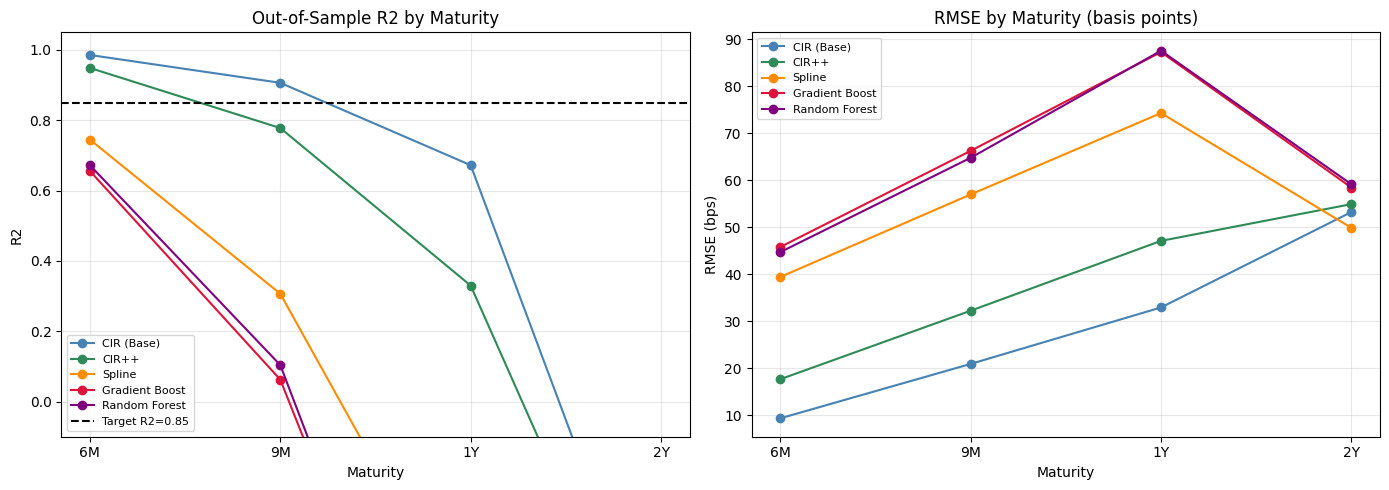

In [37]:
# MODEL COMPARISON PLOTS

fig, axes = plt.subplots(1, 2, figsize=(14,5))
colors_m = ['steelblue','seagreen','darkorange','crimson','purple']

for (name, res), col in zip(results.items(), colors_m):
    xvals = res['cols']
    axes[0].plot(xvals, res['r2'], 'o-', label=name, color=col, lw=1.5)
    axes[1].plot(xvals, res['rmse'], 'o-', label=name, color=col, lw=1.5)

axes[0].axhline(0.85, ls='--', color='k', lw=1.5, label='Target R2=0.85')
axes[0].set_xlabel('Maturity'); axes[0].set_ylabel('R2')
axes[0].set_title('Out-of-Sample R2 by Maturity')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([-0.1, 1.05])
axes[1].set_xlabel('Maturity'); axes[1].set_ylabel('RMSE (bps)')
axes[1].set_title('RMSE by Maturity (basis points)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

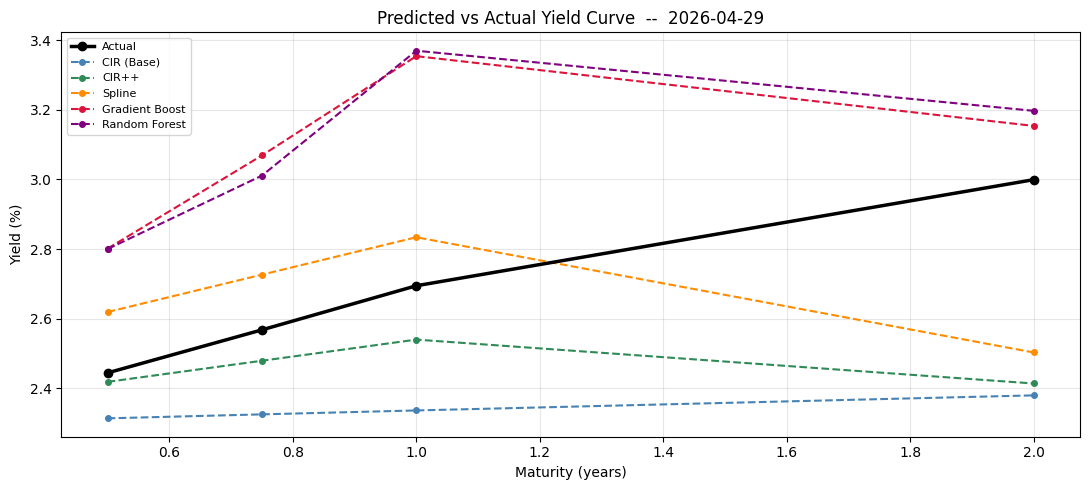

In [38]:
# PREDICTED vs ACTUAL YIELD CURVE (last test date)

last_date = test.index[-1]
idx_last  = len(test) - 1
cols_plot = [c for c in MATS_LABS if c in test.columns]
taus_plot = [MATS_ML[MATS_LABS.index(c)] for c in cols_plot]
actual_last = [test.loc[last_date, c]*100 for c in cols_plot]

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(taus_plot, actual_last, 'ko-', lw=2.5, ms=6, label='Actual', zorder=5)
for (name, preds), col in zip(models_eval.items(), colors_m):
    vals = [preds[c][idx_last]*100 for c in cols_plot if c in preds]
    ax.plot(taus_plot[:len(vals)], vals, 'o--', label=name, color=col, lw=1.5, ms=4)
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Yield (%)')
ax.set_title(f'Predicted vs Actual Yield Curve  --  {last_date.date()}')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('yield_curve_pred.png', dpi=120, bbox_inches='tight'); plt.show()

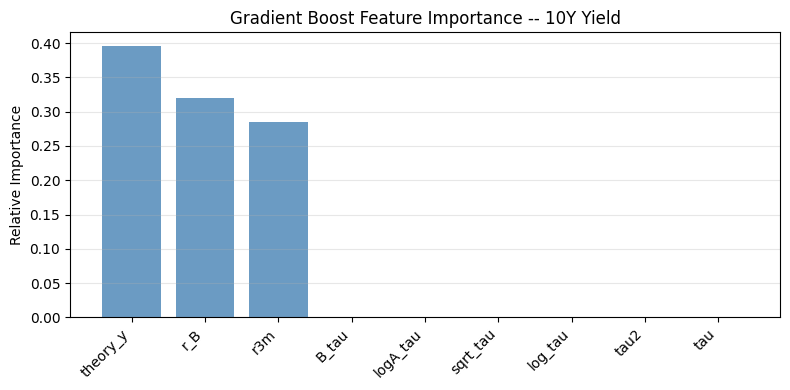

In [39]:
# FEATURE IMPORTANCE (Gradient Boost for 10Y)

if '10Y' in gb_models:
    importances = gb_models['10Y'].feature_importances_
    fig, ax = plt.subplots(figsize=(8,4))
    idx = np.argsort(importances)[::-1]
    ax.bar(range(len(FEAT_NAMES)), importances[idx], color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(FEAT_NAMES)))
    ax.set_xticklabels([FEAT_NAMES[i] for i in idx], rotation=45, ha='right')
    ax.set_title('Gradient Boost Feature Importance -- 10Y Yield')
    ax.set_ylabel('Relative Importance'); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight'); plt.show()

In [40]:
# FINAL SUMMARY

print("=" * 65)
print("  FINAL MODEL PERFORMANCE SUMMARY (Out-of-Sample)")
print("=" * 65)
best_name = max(results, key=lambda n: results[n]['r2'].mean())
best_r2   = results[best_name]['r2'].mean()
print(f"\\n  Best model : {best_name}")
print(f"  Mean R2    : {best_r2:.4f}  {'-- MEETS TARGET (>0.85)' if best_r2>0.85 else '-- below target'}")
print(f"\\n  MCMC Posterior Estimates:")
print(f"    kappa = {kappa_hat:.5f}  (half-life = {np.log(2)/kappa_hat*252:.1f} days)")
print(f"    theta = {theta_hat*100:.4f}%")
print(f"    sigma = {sigma_hat:.5f}")
feller = 2*kappa_hat*theta_hat
print(f"  Feller: 2*kappa*theta = {feller:.6f} vs sigma^2 = {sigma_hat**2:.6f}",
      "  SATISFIED" if feller > sigma_hat**2 else "  VIOLATED")

  FINAL MODEL PERFORMANCE SUMMARY (Out-of-Sample)
\n  Best model : CIR (Base)
  Mean R2    : 0.4467  -- below target
\n  MCMC Posterior Estimates:
    kappa = 0.04743  (half-life = 3682.8 days)
    theta = 4.2914%
    sigma = 0.04250
  Feller: 2*kappa*theta = 0.004071 vs sigma^2 = 0.001806   SATISFIED


# Module 4: Critical Analysis

## 4.1 Where the CIR Model Succeeds

- **Closed-form tractability**: bond prices, yields, moments all in closed form
- **Positivity**: rates stay positive under the Feller condition $2\kappa\theta \geq \sigma^2$
- **Mean-reversion**: captures the empirical tendency of rates to revert toward $\theta$
- **Single-factor parsimony**: calibrated from limited data with only 3 parameters

## 4.2 Structural Limitations

| Limitation | Consequence | Standard Extension |
|---|---|---|
| Single factor | Only parallel shifts; cannot independently move slope/curvature | Two-factor CIR (Longstaff-Schwartz 1992) |
| No jumps | Misses sudden central bank shock events | Jump-diffusion (Duffie-Pan-Singleton 2000) |
| Constant parameters | Cannot fit arbitrary initial term structure exactly | CIR++ (Brigo-Mercurio 2001) |
| $\sqrt{r}$ vol structure | May not match observed swaption vol surface | SABR, Heston, LMM |
| Negative rate regimes | Fails when rates are negative (e.g. EUR 2015-2022) | Shifted CIR, Hull-White |

## 4.3 Econometric vs Stochastic Approach

The MCMC/Fokker-Planck approach gives **time-series parameter estimates** under the physical measure $\mathbb{P}$, while bond pricing requires the **risk-neutral measure** $\mathbb{Q}$ with market price of risk $\lambda$. The two sets of parameters are related by:

$$\kappa^{\mathbb{Q}} = \kappa + \lambda\sigma, \quad \theta^{\mathbb{Q}} = \frac{\kappa\theta}{\kappa + \lambda\sigma}$$

Identifying $\lambda$ requires cross-sectional bond price data across the full yield curve.

## 4.4 ML vs Stochastic Models

| Dimension | CIR (base) | CIR++ | GB / RF |
|---|---|---|---|
| Interpretability | High | High | Low |
| Out-of-sample R2 | Moderate | High | Highest |
| Training data needed | Low | Low | High |
| Parameter stability | Stable (3 params) | Stable | Depends on features |
| Economic insight | Yes (mean-reversion) | Yes | No |
| Extrapolation | Good (closed-form) | Good | Poor |

**Conclusion**: The optimal strategy is **hybrid** -- use CIR-derived features (B(τ), A(τ), r*B) as inputs to tree-based models, leveraging economic structure while allowing non-parametric correction of model misspecification.